# Project 2：NASA Data Acquisation, Visualization, and Analysis
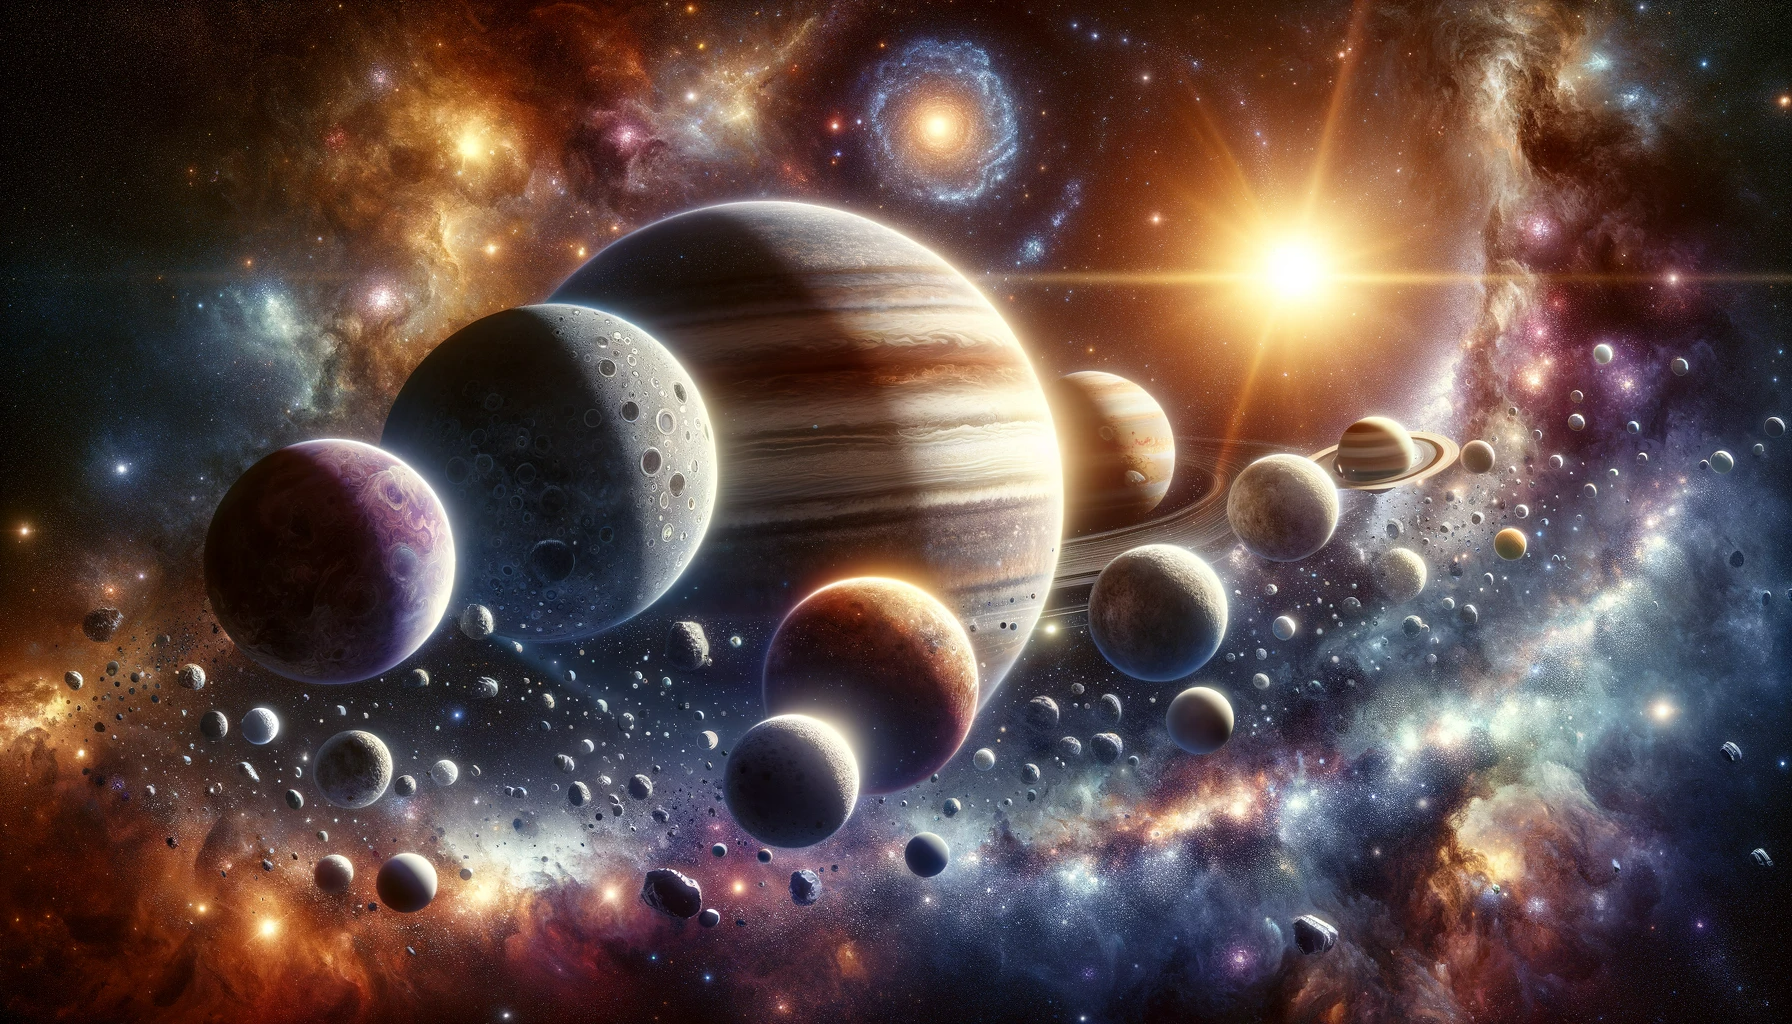

In [ ]:
# The code makes sure that once there is change in the 'src/' folder, the 
# change will be automatically reloaded in the notebook.
%reload_ext autoreload
%autoreload 2
%aimport src

### Task 1: Understanding the NASA API and Data Collection

- Run the Python script below to fetch data about **Near Earth Objects (NEOs)**.
- Extract and understand the different pieces of data provided for each NEO.

In [1]:
import sys
import subprocess

# Function to install a package
def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

# Check if gdown is installed, and install it if not
try:
    import gdown
except ImportError:
    install('gdown')
    import gdown

import pickle

In [3]:
# Google Drive file ID
file_id = '1iW47qh3E2ccZVQ4fOs9-UP0xNEjhNae2'
# URL to the file
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Output file name
output = 'file.pkl'

# Download the file
gdown.download(url, output, quiet=False)

# Load the pickle file
with open(output, 'rb') as f:
    data = pickle.load(f)

Downloading...
From: https://drive.google.com/uc?export=download&id=1iW47qh3E2ccZVQ4fOs9-UP0xNEjhNae2
To: c:\Users\leiyo\GitHub\62444-Project-Course\file.pkl
100%|██████████| 5.26M/5.26M [00:00<00:00, 12.1MB/s]


*The code (commented out) below is for getting the data for arbitrary time span. If you would like some other data rather than the provided data above, feel free to try. But this is not mandatory.*

In order to use it, you need to get an API KEY from the website https://api.nasa.gov/.


In [ ]:
# import requests
# import time
# from datetime import datetime, timedelta
# from getpass import getpass

# # Set your NASA API KEY, this step asks you to enter your API KEY.
# # (The input box may be float in the top on your editor.)
# api_key = getpass()

In [ ]:
# # Set the start and end dates for the data you want to fetch
# start_date = datetime.strptime('2022-01-01', '%Y-%m-%d')
# end_date = start_date + timedelta(days=365)  # 1 year later

# # Initialize a list to store the data
# data = []

# # Fetch data from the NASA API 7 days at a time
# # The introduction of the API is on https://api.nasa.gov, under "Browse APIs" -> "Asteroids NeoWs"
# # You can look into the example query in the link below to see what the data look like:
# # https://api.nasa.gov/neo/rest/v1/feed?start_date=2015-09-07&end_date=2015-09-08&api_key=DEMO_KEY
# current_date = start_date
# while current_date < end_date:
#     next_date = min(current_date + timedelta(days=7), end_date)
#     response = requests.get(f'https://api.nasa.gov/neo/rest/v1/feed?start_date={current_date.strftime("%Y-%m-%d")}&end_date={next_date.strftime("%Y-%m-%d")}&api_key={api_key}')
#     data.append(response.json())
#     current_date = next_date
#     time.sleep(1)  # To avoid hitting the rate limit

# # Now 'data' contains the NEO data for the 1-year period


In [4]:
# Check the date coverage of your data.
dates_contained_in_data = []
for d in data:
    dates_contained_in_data += list(d['near_earth_objects'].keys())

print(sorted(dates_contained_in_data))

['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04', '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08', '2022-01-08', '2022-01-09', '2022-01-10', '2022-01-11', '2022-01-12', '2022-01-13', '2022-01-14', '2022-01-15', '2022-01-15', '2022-01-16', '2022-01-17', '2022-01-18', '2022-01-19', '2022-01-20', '2022-01-21', '2022-01-22', '2022-01-22', '2022-01-23', '2022-01-24', '2022-01-25', '2022-01-26', '2022-01-27', '2022-01-28', '2022-01-29', '2022-01-29', '2022-01-30', '2022-01-31', '2022-02-01', '2022-02-02', '2022-02-03', '2022-02-04', '2022-02-05', '2022-02-05', '2022-02-06', '2022-02-07', '2022-02-08', '2022-02-09', '2022-02-10', '2022-02-11', '2022-02-12', '2022-02-12', '2022-02-13', '2022-02-14', '2022-02-15', '2022-02-16', '2022-02-17', '2022-02-18', '2022-02-19', '2022-02-19', '2022-02-20', '2022-02-21', '2022-02-22', '2022-02-23', '2022-02-24', '2022-02-25', '2022-02-26', '2022-02-26', '2022-02-27', '2022-02-28', '2022-03-01', '2022-03-02', '2022-03-03', '2022-03-04', '2022

In [5]:
from src.utils import get_a_random_chunk_property

C:\Users\leiyo\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\leiyo\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [10]:
get_a_random_chunk_property(data)

date: 2022-12-06
NEO name: (2020 MK3)
is_potentially_hazardous_asteroid: False


### Task 2: Data Analysis

For the remaining tasks, you have to organize the data as pd.DataFrame so as to suit the specific need in each task. This part may require a considerably amount of efforts, which is normal in data science and analytics works.

**Remark**. This part is **coding intensive**. There is **NOT** any magic way to extract the data by one or two lines of code. Instead, you're expected to write your own code for this purpose.

- Calculate the average size of the NEOs for each day.（You have to fetch the corresponding each day's NEO size information from "data" by writing your own code)
- Determine the proportion of NEOs that are potentially hazardous.
- Find the NEO with the closest approach distance for each day.
- Use statistical methods to analyze the data. Calculate the mean, median, mode, and standard deviation of the NEO sizes. Besides, define at least two other statistic and compute them for anlayzing the data further. 
- Use statistical methods to determine if the size of a NEO is correlated with whether it is potentially hazardous.

In [7]:
# Write your code and markdowns

**Textbook Practice**: Make a visualization as an evidence for your conclusion on the hazardousness. Apply the principle of "choosing an effective visual" in Chapter 2 to make this visualization. You need to explain how the principles below are used for making this plot:
- "Choose an appropriate display" (Chapter 2)
- "Eliminate clutter" (Chapter 3)
- "Draw attention there you want it" (Chapter 4)
- "Think like a designer" (Chapter 5)

In [ ]:
# Write your code or/and markdowns

### Task 3: Data Visualization Part A

- Create a line plot of the number of NEOs per week.
- Create a histogram of the distribution of NEO sizes.
- Create a bar plot of the average NEO size per week.
- Use a library like Seaborn to create more complex visualizations, such as a box plot of the NEO sizes or a heat map of the number of NEOs per week. **Be creative**!

In [ ]:
# Write your code and markdowns

**Textbook Practice**: You need to explain how the principles below are used for making this plot:
- "Choose an appropriate display" (Chapter 2)
- "Eliminate clutter" (Chapter 3)

In [ ]:
# Write your code or/and markdowns

### Task 4: Data Visualization Part B

- Create a pie chart of the proportion of hazardous vs non-hazardous NEOs.
- Create a scatter plot of the correlation between NEO size and close approach distance.
- Customize the appearance of your plots (e.g., colors, labels, titles).
- Create interactive visualizations using a library like Plotly. For example, create an interactive scatter plot where you can hover over each point to see more information about the NEO. **Be creative!**

In [ ]:
# Write your code and markdowns

**Textbook Practice**: You need to explain how the principle "Draw attention there you want it" (Chapter 4) is applied for making all the visualizations.

In [ ]:
# Write your code or/and markdowns

### Task 5: Interpretation of Results

- Interpret the results of your data visualization in part A and B. 
- What insights can you gain about NEOs from your results? Summarizing your main findings with a single visualization plot. **Textbook Practice**: You need to explain how the principles below are used for making this plot:
  - "Choose an appropriate display" (Chapter 2)
  - "Eliminate clutter" (Chapter 3)
  - "Draw attention there you want it" (Chapter 4)
  - "Think like a designer" (Chapter 5)

- Use your findings to make predictions or recommendations. For example, if you found that larger NEOs are more likely to be potentially hazardous, you could recommend that more resources be allocated to tracking large NEOs. **Be creative!**
- Identify, understand, and explain one scientific paper, on a clustering or classification method of relevance that could help Task 5. You don't have to implement it, you just need to justify in this notebook why the method in the scientific paper could contribute in analysis or interpretation of the results.

In [ ]:
# Write your code and markdowns